(rank_estimation)=
# Rank Estimation

If interparticle interaction effects can be ignored, the rank of the data set (as a matrix) can be considered equal to the number of components. In this sense, the rank of UV data is equal to the number of components while that of X-ray data can be greater.

To be practical, we will first idetify the components by decomposition and then decide the rank of each component peak to be either 1 ro 2. For example, the ranks of component peaks would be [1, 1, 1], in the order of elution, for the "SAMPLE1" data since there observed are no significant signs of interparticle effects.

We will explore briefly this rank estimation problem below. 

## Human Observation



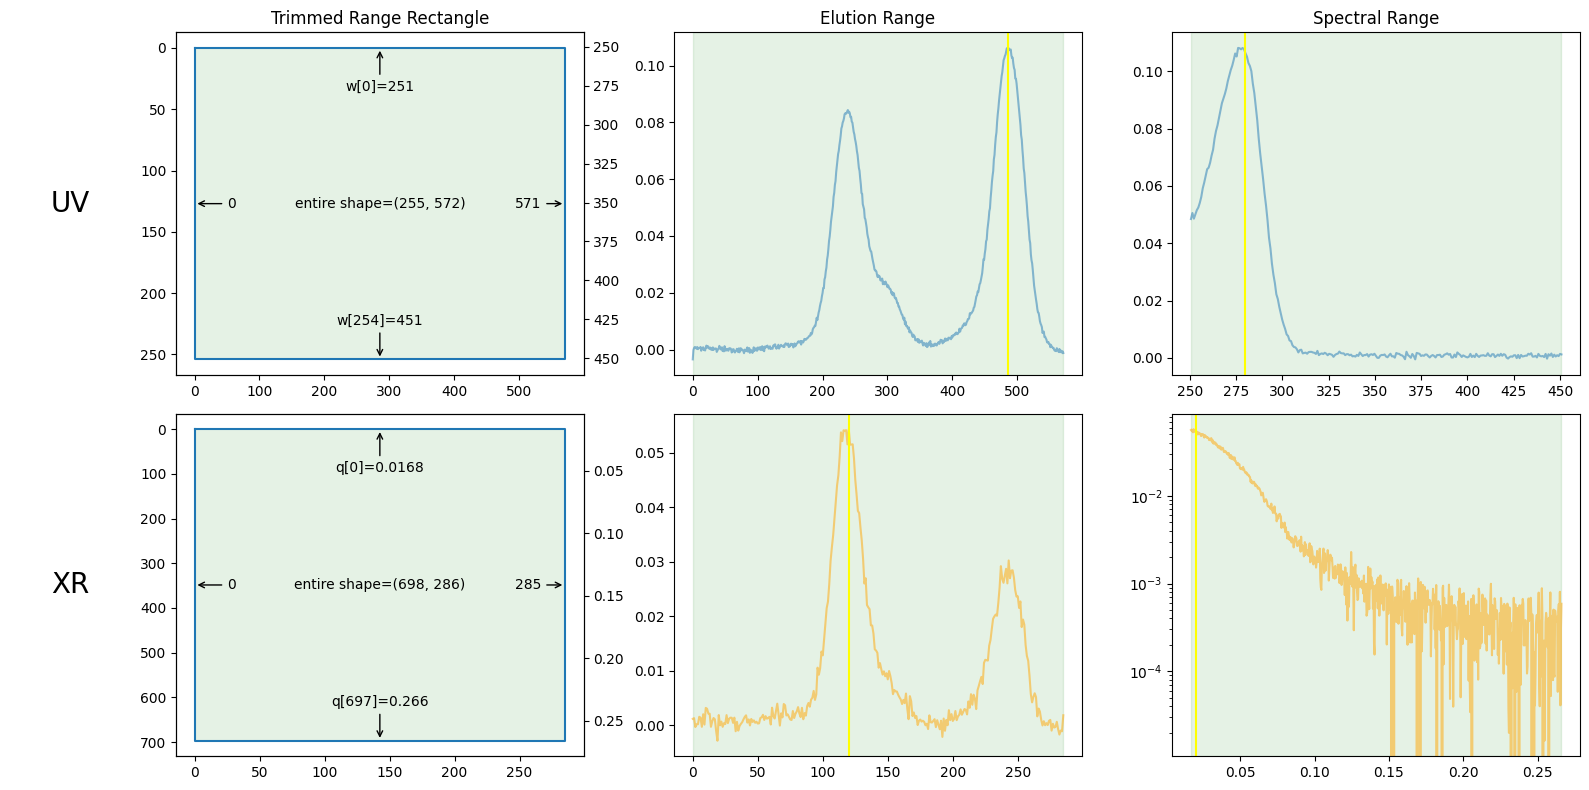

In [1]:
import sys
sys.path.insert(0, '../../../molass-library')
from molass import get_version
# molass 0.1.2 is not uploaded to PyPI yet. Donwload it from GitHub.
assert get_version() >= '0.1.2', "This script requires molass version 0.1.2 or higher."
from molass_data import SAMPLE1
from molass.DataObjects import SecSaxsData as SSD
ssd = SSD(SAMPLE1)
trimmed_ssd = ssd.trimmed_copy()
corrected_ssd = trimmed_ssd.corrected_copy()
corrected_ssd.plot_trimming_info();


developer memo: remember that "LowRank.CoupledAdjuster.select_components" is not implemented yet.


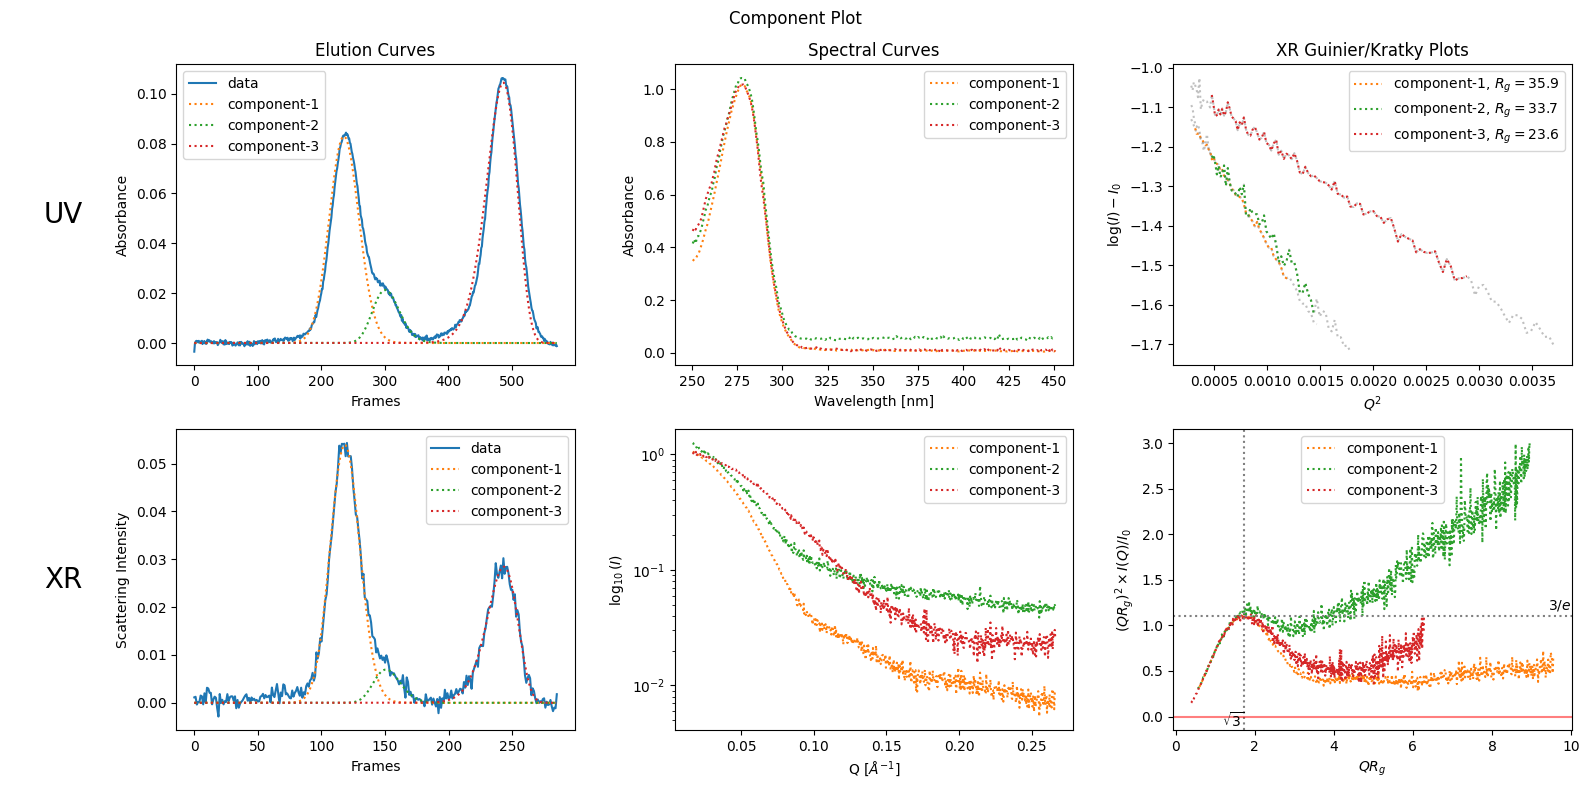

In [2]:
decomposition = corrected_ssd.quick_decomposition(num_components=3)
decomposition.plot_components();

## Absorbance / Scattering Ratio


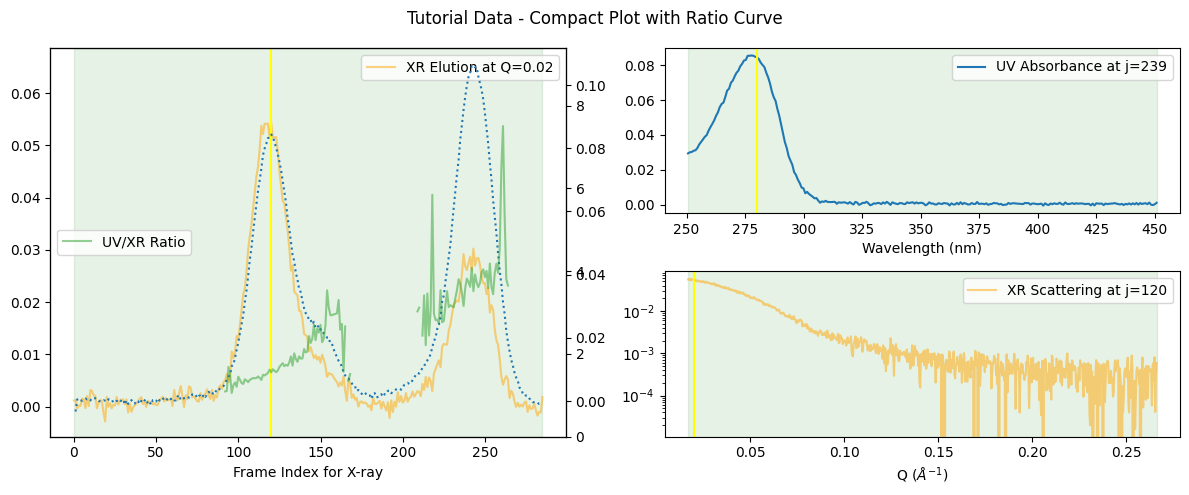

In [3]:
corrected_ssd.plot_compact(ratio_curve=True, title="Tutorial Data - Compact Plot with Ratio Curve");

## Concentration Dependence

In [4]:
scds = decomposition.compute_scds(debug=True)
scds

[0] [(104, 118), (118, 134)]
[1] [(138, 166)]
[2] [(226, 243), (243, 258)]
[0] [[35.89479541 35.86967745]
 [35.84669649 35.23413751]] 0.0007000109771497765
[2] [[23.68821716 23.65293418]
 [23.62066584 23.45551684]] 0.0014905838464534396
[0] [104, 118, 134]
s[0:2]= [1.82019908 0.01689492]
[1] (138, 152, 166)
s[0:2]= [0.41600213 0.02187921]
[2] [226, 243, 258]
s[0:2]= [1.26471661 0.01679839]
cds_list: [(118, 0.237627986382854), (152, 4.642764861594007), (243, 1.5212556670108408)]


[0.237627986382854, 4.642764861594007, 1.5212556670108408]

In [5]:
from molass.Backward.RankEstimator import scd_to_rank
ranks = [scd_to_rank(scd) for scd in scds]
for scd, rank in zip(scds, ranks):
    print(f"SCD: {scd}, Rank: {rank}")

SCD: 0.237627986382854, Rank: 1
SCD: 4.642764861594007, Rank: 1
SCD: 1.5212556670108408, Rank: 1


In [6]:
decomposition.update_xr_ranks(ranks)
decomposition.get_xr_components()

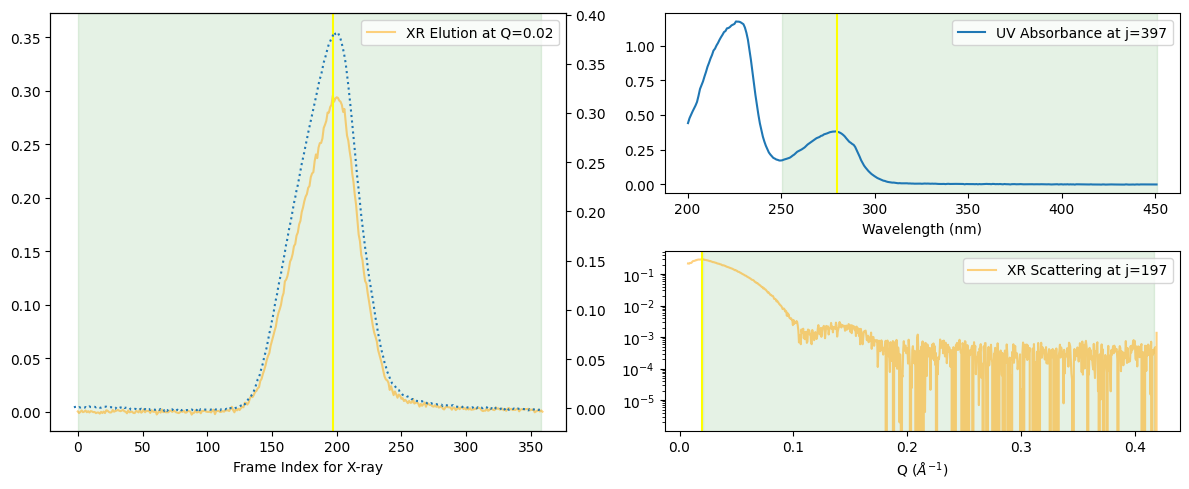

In [7]:
from molass_data import SAMPLE3
ssd3 = SSD(SAMPLE3)
ssd3.plot_compact()

In [8]:
decomposition3 = ssd3.quick_decomposition()
scds = decomposition3.compute_scds()
scds

developer memo: remember that "LowRank.CoupledAdjuster.select_components" is not implemented yet.


[0] [(163, 196), (196, 224)]
[0] [[35.19829792 35.30132337]
 [33.7723204  33.41936602]] -0.0029227236447218613
[0] [163, 196, 224]
s[0:2]= [13.22854134  0.28325752]
cds_list: [(196, 5.246897979988885)]


[5.246897979988885]

In [9]:
ranks = [scd_to_rank(scd) for scd in scds]
for scd, rank in zip(scds, ranks):
    print(f"SCD: {scd}, Rank: {rank}")

SCD: 5.246897979988885, Rank: 2
